# 09 - Data Quality Assessment (Production Dataset)
## ShopEase Europe | Sentiment Analysis Project - Phase 2 
**Objective:** Conduct a thorough data quality audit of the real Amazon 
customer review dataset, mirroring the methodology applied in Phase 1 
while specifically investigating how this dataset differs from the 
synthetic data that prompted this second phase.

In [2]:
# Import Libaries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


#### Load the Dataset

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'amazon_reviews_cleaned.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(RAW_DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Data file exists: {os.path.exists(RAW_DATA_PATH)}")

Dataset loaded: 21,055 rows x 7 columns
Data file exists: True


## Schema Validation
Confirming structure, data types and completeness of the production dataset.

In [4]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

print(f"{'Column':<25} {'Dtype':<15} {'Non-Null':<15} {'Nulls'}")
print("-" * 60)
for col in df.columns:
    nulls = df[col].isnull().sum()
    print(f"{col:<25} {str(df[col].dtype):<15} {df[col].count():<15,} {nulls}")

print("\nSample records:")
display(df.head())

Shape: 21,055 rows x 7 columns

Column                    Dtype           Non-Null        Nulls
------------------------------------------------------------
review_id                 object          21,055          0
product_category          object          21,055          0
timestamp                 object          21,055          0
country                   object          21,054          1
rating                    int64           21,055          0
review                    object          21,055          0
sentiment                 object          21,055          0

Sample records:


,review_id,product_category,timestamp,country,rating,review,sentiment
0,REV-50BCBCD9,Sports,2024-09-16 13:44:26+00:00,US,1,"I registered on the website, tried to order a ...",Negative
1,REV-6D2B2651,Toys,2024-09-16 18:26:46+00:00,GB,1,Had multiple orders one turned up and driver h...,Negative
2,REV-F7E80372,Toys,2024-09-16 21:47:39+00:00,GB,1,I informed these reprobates that I WOULD NOT B...,Negative
3,REV-ED2B173F,Sports,2024-09-17 07:15:49+00:00,AU,1,I have bought from Amazon before and no proble...,Negative
4,REV-E48A7AB9,Fashion,2024-09-16 18:37:17+00:00,GB,1,If I could give a lower rate I would! I cancel...,Negative


## Schema Findings

The dataset contains 21,055 rows and 7 columns- review_id, 
product_category, timestamp, country, rating, review and sentiment.

One missing value identified in the country column. Sentiment labels 
are capitalised ("Negative", "Positive", "Neutral") and will be 
standardised to lowercase during cleaning.

#### Checking for duplicates

In [5]:
print("Duplicate review_id:", df['review_id'].duplicated().sum())
print("Duplicate review text:", df['review'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())
print(f"\nUnique review texts: {df['review'].nunique():,} out of {len(df):,} total")

Duplicate review_id: 0
Duplicate review text: 648
Fully duplicate rows: 0

Unique review texts: 20,407 out of 21,055 total


## Duplicate Review Finding

97% of review texts are unique (20,407 of 21,055), with only 648 
duplicate texts and zero duplicate review IDs. This level of overlap 
is consistent with genuine customer feedback, where independent 
customers occasionally express similar sentiments using similar 
wording, rather than indicating templated or artificially generated text.

## Sentiment Distribution

SENTIMENT DISTRIBUTION
Negative      14,350  (68.15%)
Positive       5,820  (27.64%)
Neutral          885  (4.2%)


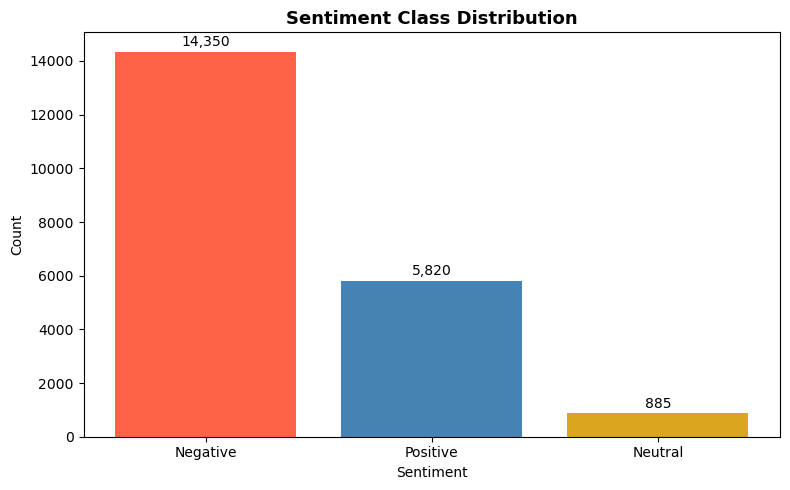

In [6]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = (df['sentiment'].value_counts(normalize=True) * 100).round(2)

print("SENTIMENT DISTRIBUTION")
for label in sentiment_counts.index:
    print(f"{label:<12} {sentiment_counts[label]:>7,}  ({sentiment_pct[label]}%)")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato', 'steelblue', 'goldenrod']
ax.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
ax.set_title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.grid(False)

for i, (label, count) in enumerate(sentiment_counts.items()):
    ax.text(i, count + 200, f'{count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_sentiment_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Sentiment Distribution Insight

**Finding:** Negative sentiment dominates this dataset at 68.15% 
(14,350 reviews), followed by positive at 27.64% (5,820) and neutral 
at just 4.2% (885). This skew toward negative sentiment is typical of 
unprompted customer review platforms, where dissatisfied customers are 
disproportionately motivated to leave feedback compared to satisfied ones.

**Insight:** The near-absence of neutral reviews (4.2%) presents a 
modelling challenge, with fewer than 900 examples, the neutral class 
risks being poorly learned by any classifier, regardless of algorithm 
choice. This imbalance is more severe than typical sentiment datasets 
and will require careful handling through class weighting or 
oversampling during model training.

## Rating vs Sentiment Consistency

In [7]:
cross_tab = pd.crosstab(df['rating'], df['sentiment'])
display(cross_tab)

cross_tab_pct = pd.crosstab(df['rating'], df['sentiment'], normalize='index').round(3) * 100
display(cross_tab_pct)

sentiment,Negative,Neutral,Positive
rating,,,
1,13123,0,0
2,1227,0,0
3,0,885,0
4,0,0,1292
5,0,0,4528


sentiment,Negative,Neutral,Positive
rating,,,
1,100.0,0.0,0.0
2,100.0,0.0,0.0
3,0.0,100.0,0.0
4,0.0,0.0,100.0
5,0.0,0.0,100.0


## Rating-Sentiment Mapping Finding

Sentiment labels show perfect, deterministic alignment with numeric 
ratings across all 21,055 records. Ratings 1-2 are always labelled 
negative, rating 3 is always neutral, and ratings 4-5 are always 
positive, with zero exceptions.

**Insight:** This pattern strongly suggests sentiment labels were 
derived programmatically from the numeric rating rather than 
independently assigned through human judgement of review text. While 
this does not affect the authenticity of the underlying review text which remains genuine, varied customer writing it means our model 
will effectively be learning to predict rating-derived categories. 
A review with negative language about delivery but an overall positive 
product experience would still be labelled by its numeric rating alone, 
not by nuanced reading of the text. This is a reasonable and common 
labelling approach in practice, but worth noting as a methodological 
boundary when interpreting model performance.